In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from unsflow.utils.plot_styles import *

In [2]:
files = [
    '../KT_2.5/results/unstable.pkl',
    '../KT_2.75/results/unstable.pkl',
    '../KT_3.0/results/unstable.pkl',
    '../KT_3.5/results/unstable.pkl',
    '../KT_4.0/results/unstable.pkl',
    '../KT_4.5/results/unstable.pkl',
    '../KT_5.0/results/unstable.pkl',
]

In [3]:
dataset = []
for file in files:
    with open(file, 'rb') as f:
        res = pickle.load(f)
    dataset.append(res)

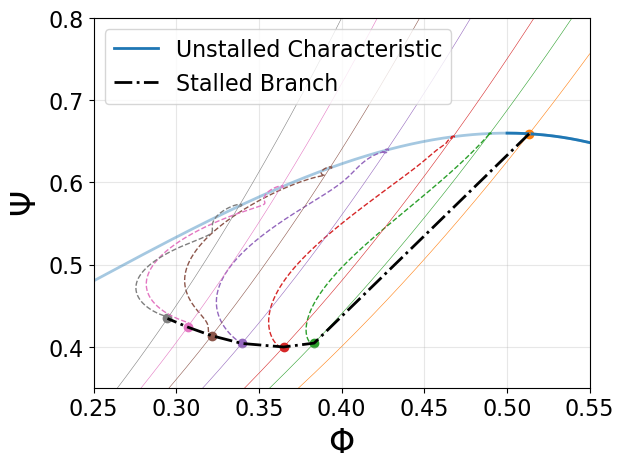

In [15]:
xp, yp = [], []

for ii,data in enumerate(dataset):
    phi = data.phi
    psi_c = data.psi_c
    psi_v = data.psi_v
    sol = data.solutionMooreGreitzer
    
    if ii==0:
        plt.plot(phi[phi>0.5], psi_c[phi>0.5], label='Unstalled Characteristic', lw=2.0)
        plt.plot(phi, psi_c, '-C0', lw=2.0, alpha=0.4)
    plt.plot(phi, psi_v, '-C%i' %(ii+1), lw=0.4)
    plt.plot(sol[:,1], sol[:,0], '--C%i' %(ii+1), lw=1.0)
    plt.scatter(sol[-1,1], sol[-1,0], c='C%i' %(ii+1))
    
    xp.append(sol[-1,1])
    yp.append(sol[-1,0])

plt.plot(xp, yp, '-.k', lw=2.0, label='Stalled Branch')


plt.xlabel(r'$\Phi$')
plt.ylabel(r'$\Psi$')
plt.legend()
# plt.tight_layout()
plt.grid(alpha=0.3)
plt.xlim([0.25,0.55])
plt.ylim([0.35,0.8])
plt.savefig('mooreGreitzer_trajectory_B_05_stalled_char.pdf', bbox_inches='tight')
    
